# Predicting Late Deliveries and Optimizing Last-Mile Logistics Using Machine Learning

In [1]:
# Install Required libraries

In [2]:
%pip install tensorflow numpy pandas matplotlib seaborn scikit-learn pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install shap


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Import libraries

In [5]:
# Data Manipulation
import pandas as pd
import numpy as np
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             confusion_matrix,
                             classification_report,
                             roc_auc_score,
roc_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [6]:
pip install kaggle

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Import Data from Kaggel

In [8]:
import kaggle

# Download dataset
kaggle.api.dataset_download_files(
    'shashwatwork/dataco-smart-supply-chain-for-big-data-analysis',
    path='data',
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis


In [9]:
# Store the Kaggle Dataset to CSV

In [10]:
import pandas as pd

df = pd.read_csv(
    "data/DataCoSupplyChainDataset.csv",
    encoding='latin1'
)

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [11]:
# Data Preprocessing

In [12]:
print(df.shape)

print(df.info())

print(df.describe())

(180519, 53)
<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname              

In [13]:
# Data Cleaning - Missing Value checks

In [14]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Customer Lname              8
Customer Zipcode            3
Order Zipcode          155679
Product Description    180519
dtype: int64


In [15]:
# Check percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100

print(pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": missing_percent
}).sort_values("Missing %", ascending=False))

                               Missing Count   Missing %
Product Description                   180519  100.000000
Order Zipcode                         155679   86.239676
Customer Lname                             8    0.004432
Customer Zipcode                           3    0.001662
Days for shipment (scheduled)              0    0.000000
Sales per customer                         0    0.000000
Benefit per order                          0    0.000000
Delivery Status                            0    0.000000
Late_delivery_risk                         0    0.000000
Customer City                              0    0.000000
Customer Country                           0    0.000000
Category Id                                0    0.000000
Category Name                              0    0.000000
Customer Fname                             0    0.000000
Customer Email                             0    0.000000
Customer Password                          0    0.000000
Customer Id                    

In [16]:
# Data Cleaning - By dropping few columns

In [17]:
df.drop(columns=['Product Description', 'Order Zipcode'], inplace=True)

In [18]:
# Data Cleaning - Median and Mode

In [19]:
df['Customer Lname'] = df['Customer Lname'].fillna(
    df['Customer Lname'].mode()[0]
)

df['Customer Zipcode'] = df['Customer Zipcode'].fillna(
    df['Customer Zipcode'].mode()[0]
)

In [20]:
# Data quality check after data Cleaning

In [21]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [22]:
# Data Cleaning - Check for Duplicates

In [23]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

0


In [24]:
df['Late_delivery_risk'].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [25]:
df.to_csv("data/DataCoSupplyChain_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [26]:
# Feature engineering for Label Encoder

In [27]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

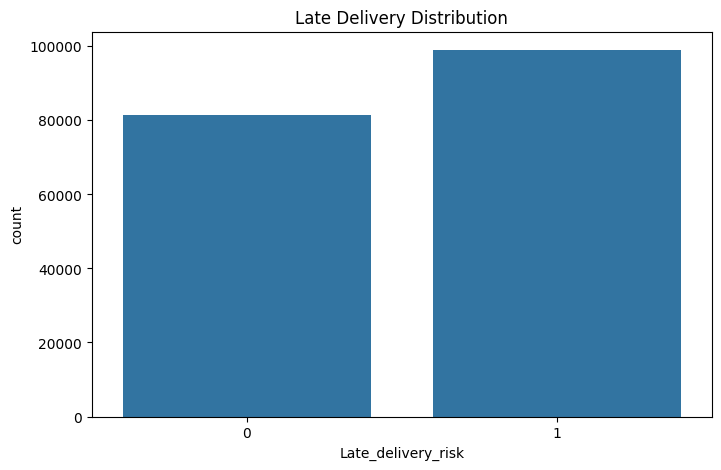

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(x='Late_delivery_risk', data=df)

plt.title("Late Delivery Distribution")

plt.show()

In [29]:
#Exploratory Data Analysis - HeatMap

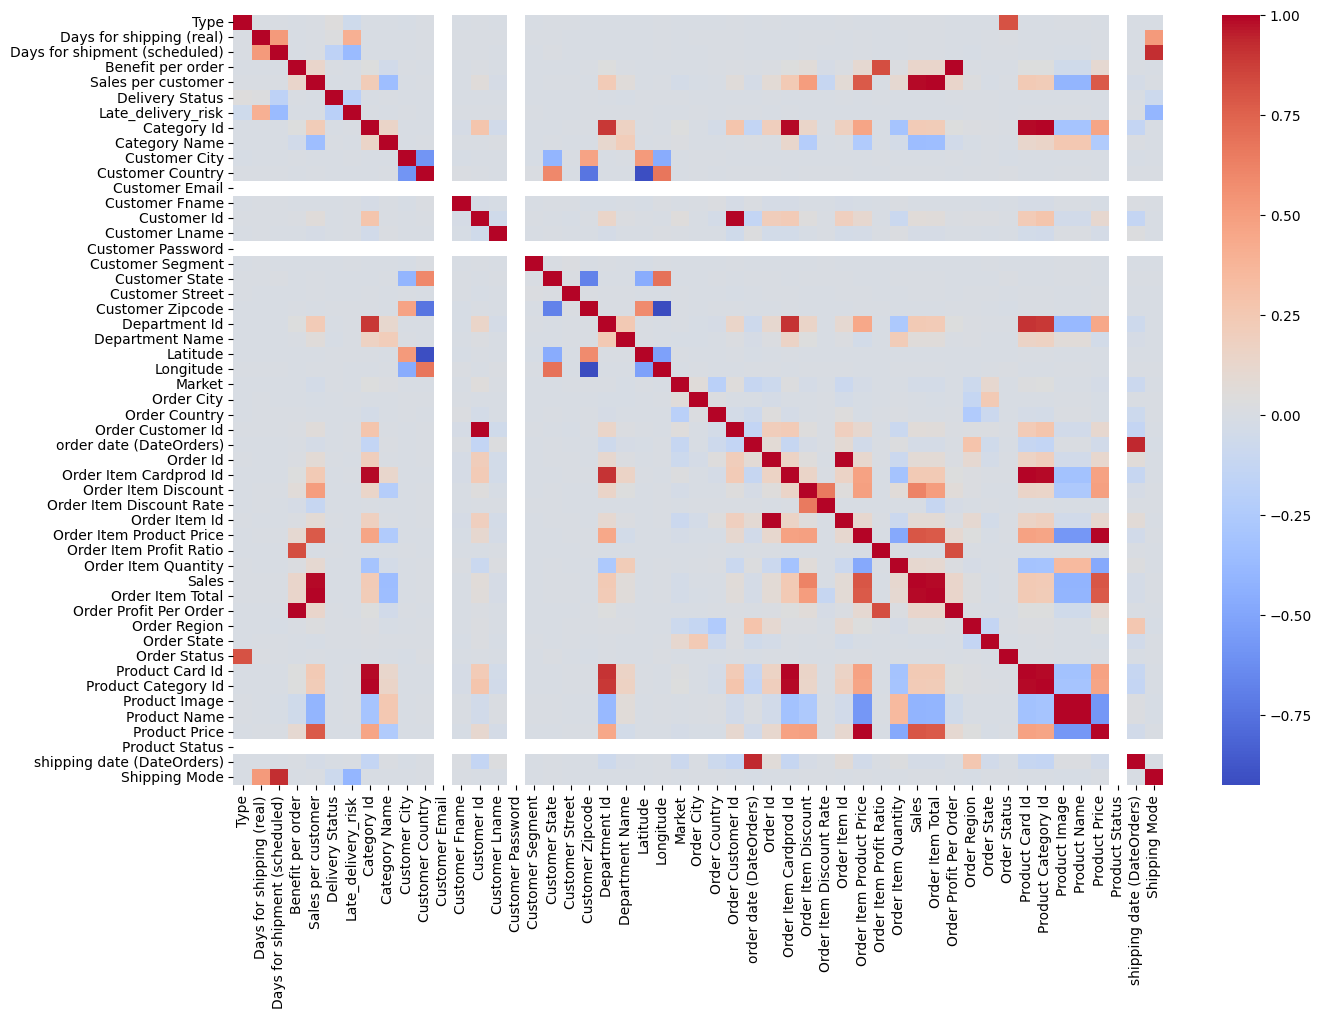

In [30]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(),
            cmap="coolwarm")

plt.show()

In [31]:
#Exploratory Data Analysis - Days of shipping

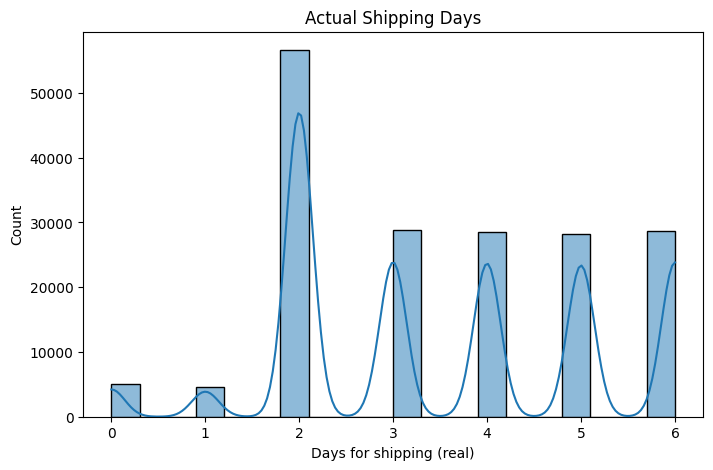

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df['Days for shipping (real)'],
             bins=20,
             kde=True)

plt.title("Actual Shipping Days")

plt.show()

In [33]:
#Exploratory Data Analysis - Sales Distribution

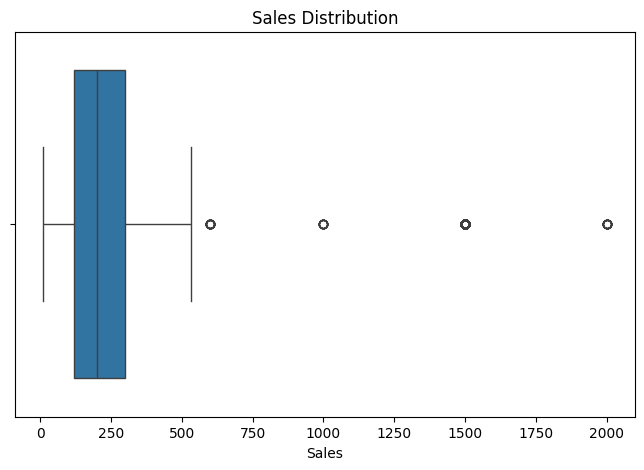

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Sales'])

plt.title("Sales Distribution")

plt.show()

In [35]:
#Exploratory Data Analysis - Shipping mode

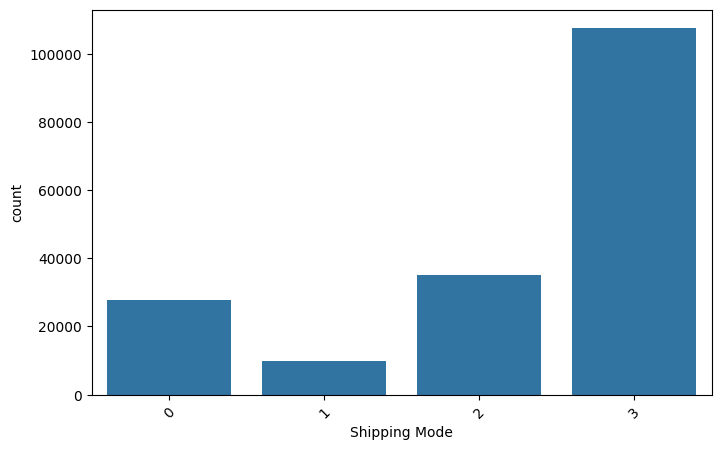

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(x='Shipping Mode',
              data=df)

plt.xticks(rotation=45)

plt.show()

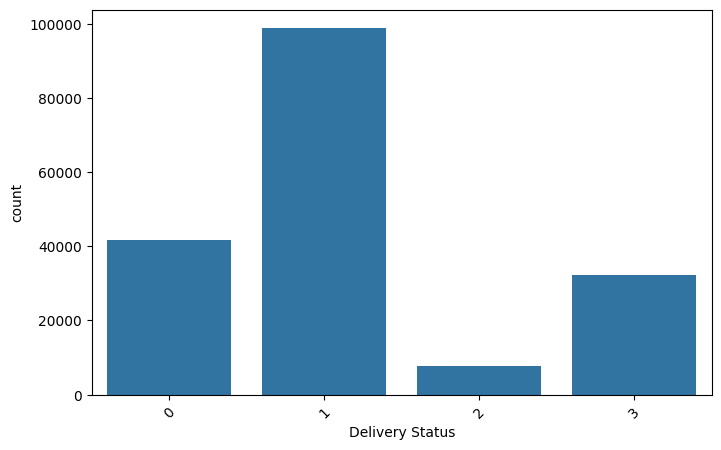

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(x='Delivery Status',
              data=df)

plt.xticks(rotation=45)

plt.show()

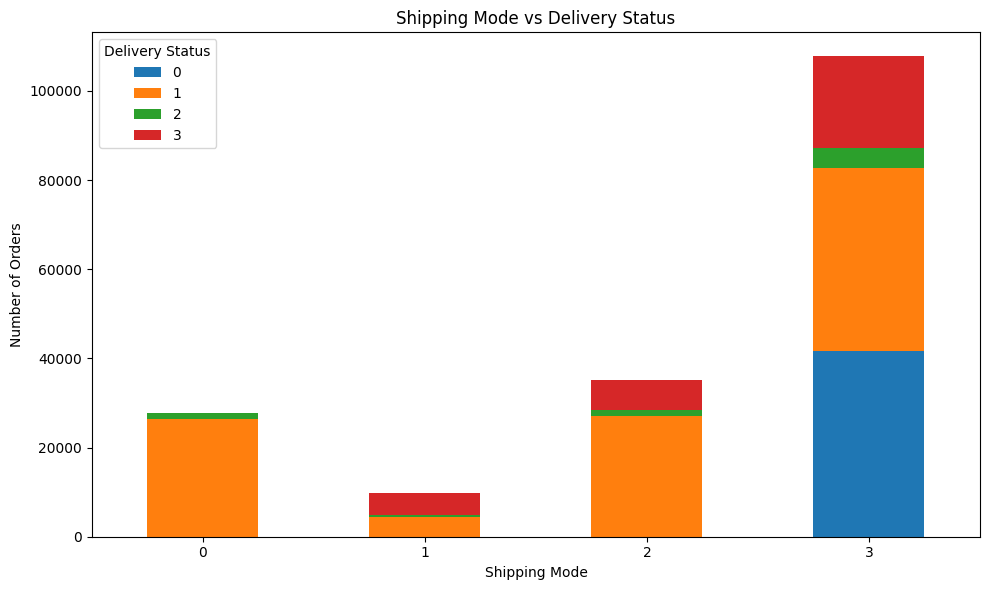

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a cross-tabulation
shipping_delivery = pd.crosstab(df['Shipping Mode'], df['Delivery Status'])

# Plot
shipping_delivery.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Shipping Mode vs Delivery Status')
plt.xlabel('Shipping Mode')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.legend(title='Delivery Status')
plt.tight_layout()
plt.show()

In [39]:
# Dimensionality Reduction

In [40]:
drop_columns = [

'Order Id',

'Customer Id',

'Customer Email',

'Customer Password',

'Product Image'

]

for col in drop_columns:
    if col in df.columns:
        df.drop(col,
                axis=1,
                inplace=True)

In [41]:
# Declare X and Y dataset

In [42]:
X = df.drop(
    columns=[
        'Late_delivery_risk',
        'Delivery Status',
        'Days for shipping (real)',
        'Days for shipment (scheduled)'
    ]
)

y = df['Late_delivery_risk']

X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42

)

In [43]:
# Logistic Regression

In [44]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [45]:
print("Accuracy:",
accuracy_score(y_test,pred_lr))

print("Precision:",
precision_score(y_test,pred_lr))

print("Recall:",
recall_score(y_test,pred_lr))

print("F1:",
f1_score(y_test,pred_lr))

y_prob_lr = lr.predict_proba(X_test)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC Score:", round(roc_auc_lr, 4))

print(classification_report(y_test,pred_lr))

Accuracy: 0.5479171282960337
Precision: 0.5484509634421795
Recall: 0.9934838611910896
F1: 0.7067447626576593
ROC-AUC Score: 0.5238
              precision    recall  f1-score   support

           0       0.47      0.01      0.01     16307
           1       0.55      0.99      0.71     19797

    accuracy                           0.55     36104
   macro avg       0.51      0.50      0.36     36104
weighted avg       0.51      0.55      0.39     36104



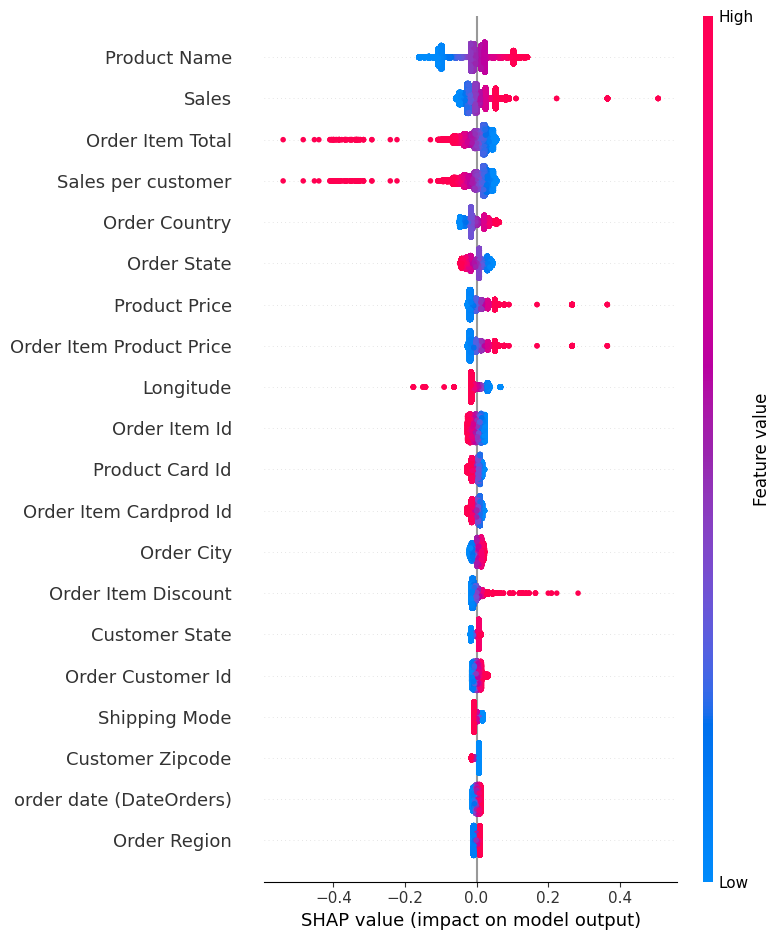

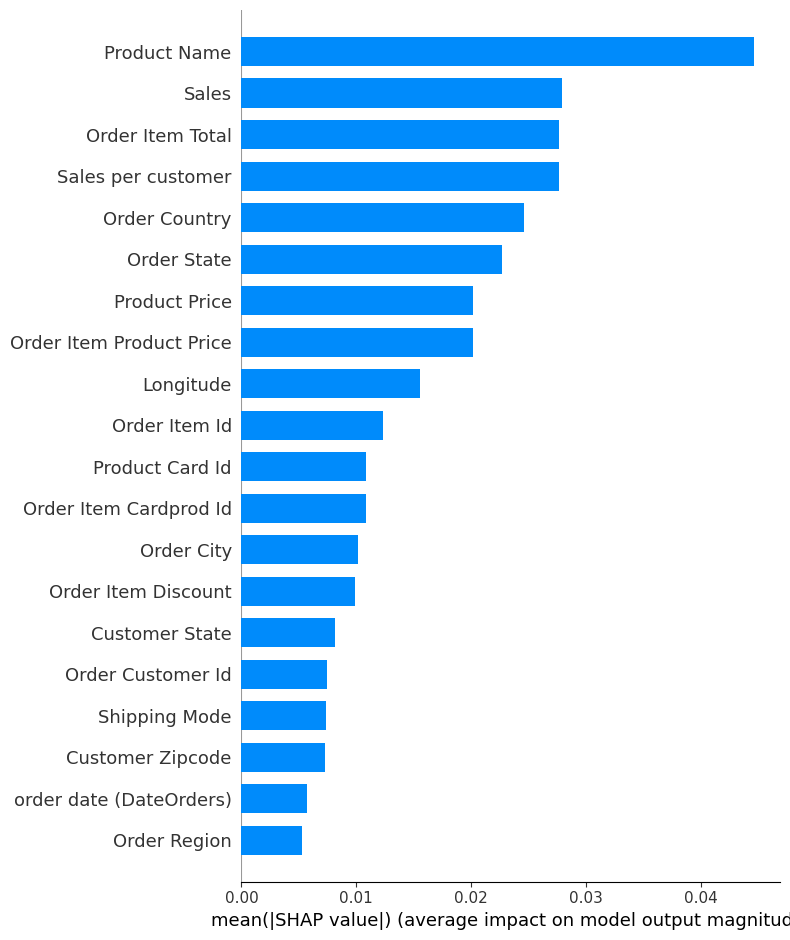

In [46]:
# SHAP Feature importance
# --------------------------------------------------
# SHAP - LOGISTIC REGRESSION
# --------------------------------------------------

explainer_lr = shap.LinearExplainer(
    lr,
    X_train
)

shap_values_lr = explainer_lr.shap_values(X_test)

shap.summary_plot(
    shap_values_lr,
    X_test
)

shap.summary_plot(
    shap_values_lr,
    X_test,
    plot_type='bar'
)

In [47]:
# Decision Tree Classifier

In [48]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

In [49]:
print("Accuracy:",
accuracy_score(y_test,pred_dt))

print("Precision:",
precision_score(y_test,pred_dt))

print("Recall:",
recall_score(y_test,pred_dt))

print("F1:",
f1_score(y_test,pred_dt))

y_prob_dt = lr.predict_proba(X_test)[:, 1]

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("ROC-AUC Score:", round(roc_auc_dt, 4))

Accuracy: 0.9274318635054287
Precision: 0.9353236352577424
Recall: 0.9321109258978633
F1: 0.9337145170267672
ROC-AUC Score: 0.5238


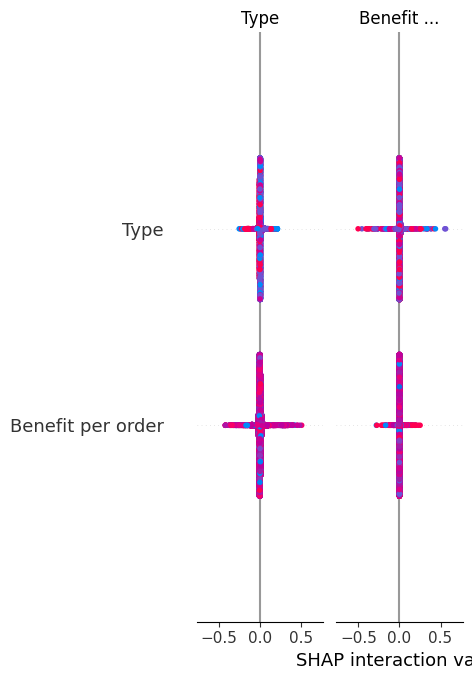

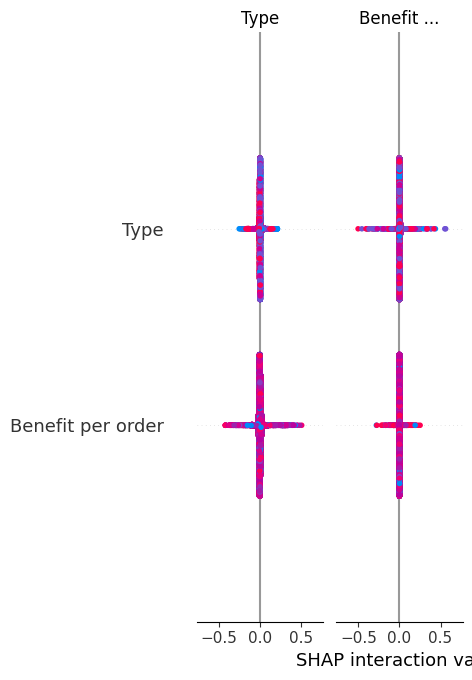

In [50]:
# --------------------------------------------------
# SHAP - DECISION TREE
# --------------------------------------------------

explainer_dt = shap.TreeExplainer(dt)

shap_values_dt = explainer_dt.shap_values(X_test)

if isinstance(shap_values_dt, list):
    shap_values_dt_plot = shap_values_dt[1]
else:
    shap_values_dt_plot = shap_values_dt

shap.summary_plot(
    shap_values_dt_plot,
    X_test
)

shap.summary_plot(
    shap_values_dt_plot,
    X_test,
    plot_type='bar'
)

In [51]:
# Random Forest

In [52]:
rf = RandomForestClassifier(

n_estimators=200,

random_state=42

)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [53]:
print("Accuracy:",
accuracy_score(y_test,pred_rf))

print("Precision:",
precision_score(y_test,pred_rf))

print("Recall:",
recall_score(y_test,pred_rf))

print("F1:",
f1_score(y_test,pred_rf))

print("ROC AUC:",
roc_auc_score(y_test,pred_rf))

Accuracy: 0.9004265455351208
Precision: 0.941712104689204
Recall: 0.8724049098348234
F1: 0.9057345884574036
ROC AUC: 0.9034251200305533


In [54]:
# Confusion Matrix

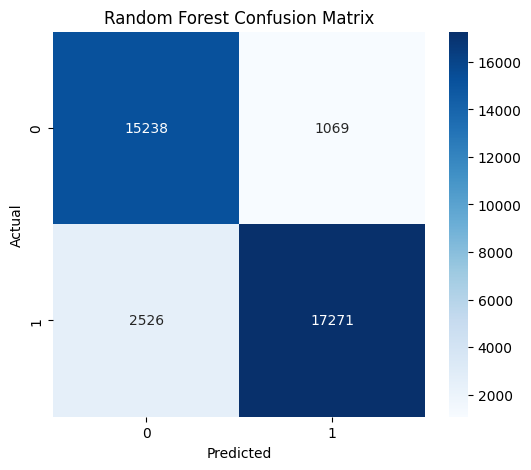

In [55]:
cm = confusion_matrix(y_test,pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [56]:
# Feature Importance

In [57]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance.head())

                       Feature  Importance
41               Shipping Mode    0.199613
34                Order Status    0.058195
40  shipping date (DateOrders)    0.042009
21     order date (DateOrders)    0.041275
11             Customer Street    0.040033


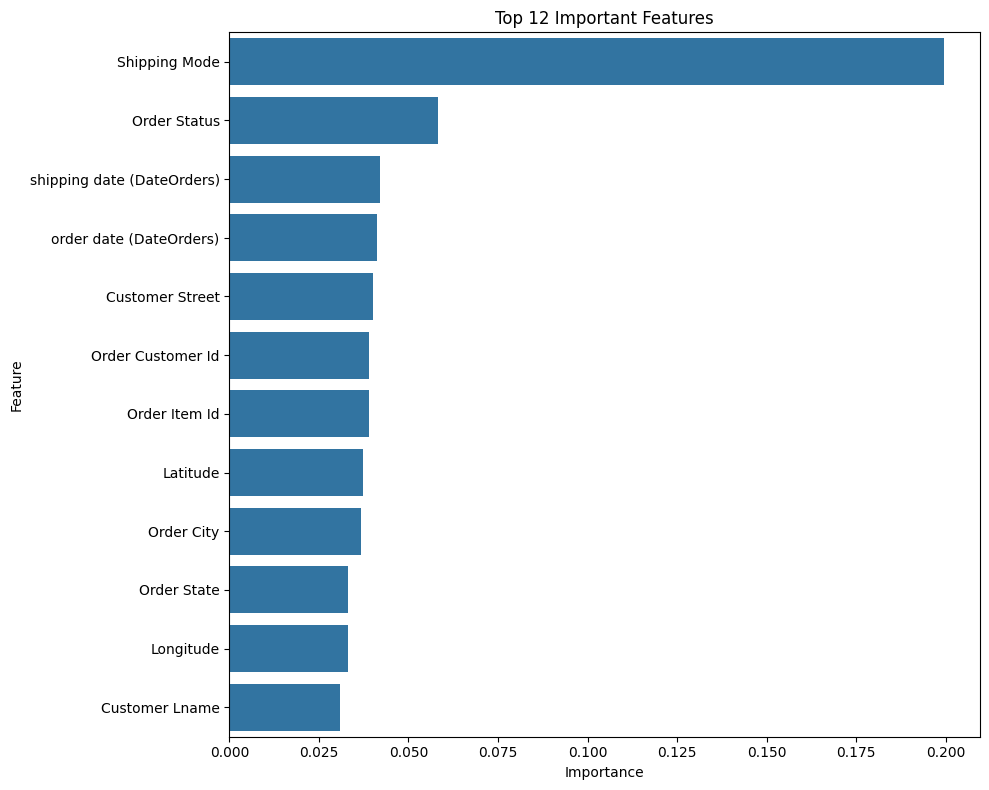

In [58]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(12),
    x='Importance',
    y='Feature'
)

plt.title("Top 12 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [59]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss'
)

In [62]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [63]:
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [64]:
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC AUC  :", round(roc_auc,4))

Accuracy : 0.8063
Precision: 0.8984
Recall   : 0.7293
F1 Score : 0.8051
ROC AUC  : 0.9173


In [65]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.73      0.90      0.81     16307
           1       0.90      0.73      0.81     19797

    accuracy                           0.81     36104
   macro avg       0.82      0.81      0.81     36104
weighted avg       0.82      0.81      0.81     36104



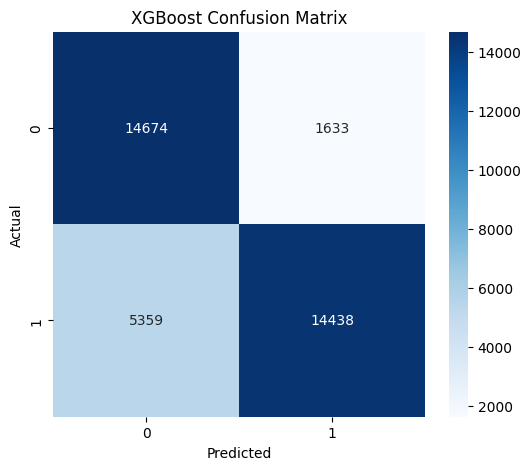

In [66]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [67]:
importance = pd.DataFrame({

'Feature':X.columns,

'Importance':rf.feature_importances_

})

importance = importance.sort_values(

'Importance',

ascending=False

)

print(importance.head(15))

                       Feature  Importance
41               Shipping Mode    0.199613
34                Order Status    0.058195
40  shipping date (DateOrders)    0.042009
21     order date (DateOrders)    0.041275
11             Customer Street    0.040033
20           Order Customer Id    0.039059
25               Order Item Id    0.038976
15                    Latitude    0.037438
18                  Order City    0.036812
33                 Order State    0.033166
16                   Longitude    0.033023
8               Customer Lname    0.030762
7               Customer Fname    0.030207
5                Customer City    0.023814
19               Order Country    0.023436


In [68]:
importance = xgb.feature_importances_

feature_importance = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    })
    .sort_values(by='Importance', ascending=False)
)

print(feature_importance.head(20))

                       Feature  Importance
41               Shipping Mode    0.427805
34                Order Status    0.158227
40  shipping date (DateOrders)    0.047038
21     order date (DateOrders)    0.044258
0                         Type    0.026543
25               Order Item Id    0.014038
19               Order Country    0.011856
18                  Order City    0.011683
32                Order Region    0.011435
8               Customer Lname    0.011419
20           Order Customer Id    0.011306
16                   Longitude    0.011230
33                 Order State    0.011080
9             Customer Segment    0.011047
10              Customer State    0.010707
11             Customer Street    0.010688
5                Customer City    0.010481
12            Customer Zipcode    0.010475
7               Customer Fname    0.010305
15                    Latitude    0.010202


In [69]:
# Feature Importance

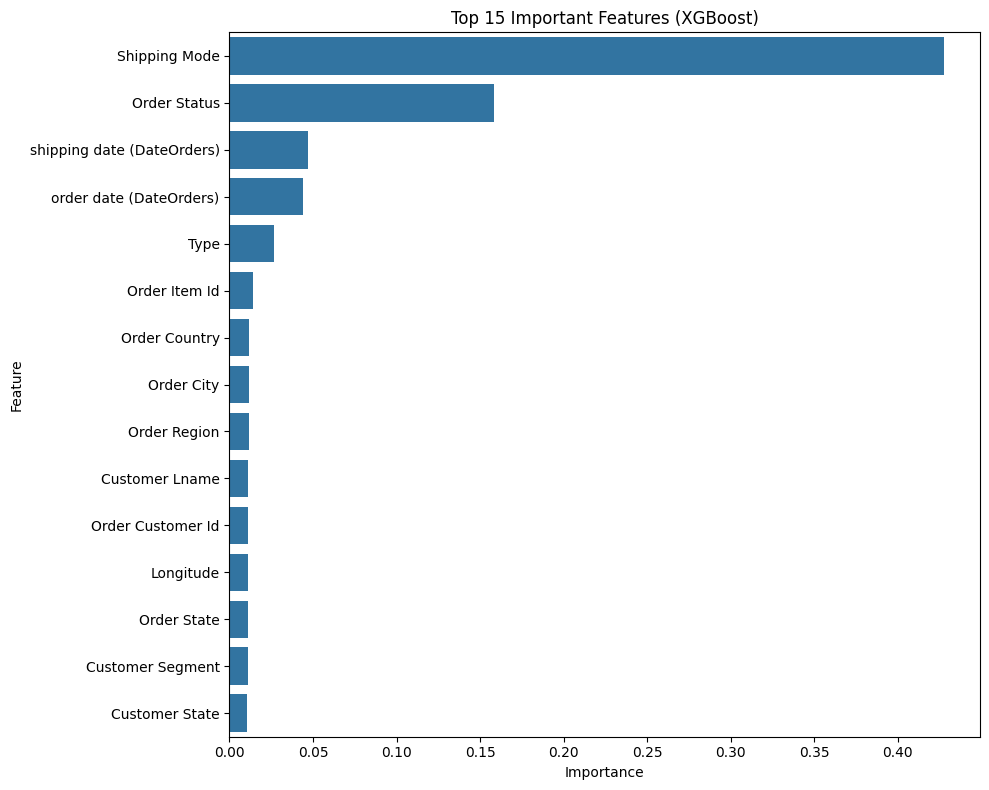

In [70]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

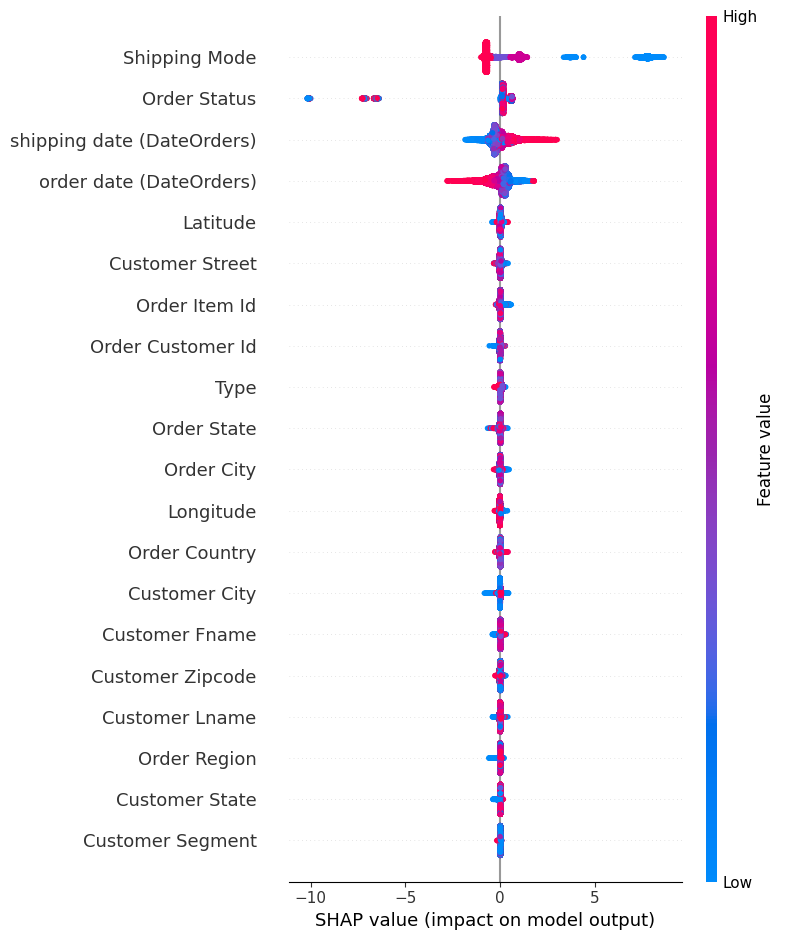

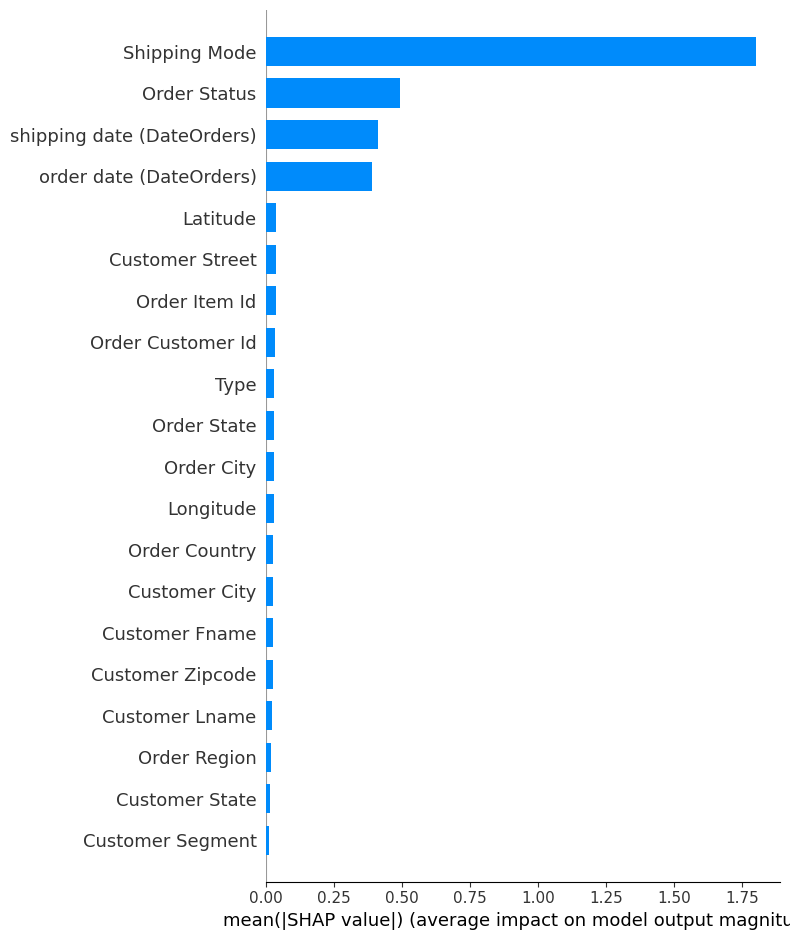

In [71]:
# --------------------------------------------------
# SHAP - XGBOOST
# --------------------------------------------------

explainer_xgb = shap.TreeExplainer(xgb)

shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(
    shap_values_xgb,
    X_test
)
shap.summary_plot(
    shap_values_xgb,
    X_test,
    plot_type='bar'
)

In [72]:
# Fine Tuned Decision Tree

In [73]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Smaller parameter search
rf_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

# Use 3-fold CV instead of 5-fold
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

rf_random = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    param_distributions=rf_param_grid,
    n_iter=10,                 # only 10 combinations
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_random.fit(X_train, y_train)

print("Best Parameters:")
print(rf_random.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_random.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Best CV ROC-AUC:
0.9325802425482853


In [74]:
best_rf = rf_random.best_estimator_

pred_ft_rf = best_rf.predict(X_test)
prob_ft_rf = best_rf.predict_proba(X_test)[:, 1]

In [75]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Smaller parameter search
xgb_param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_random.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_random.best_params_)

print("\nBest XGBoost CV ROC-AUC:")
print(xgb_random.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Best XGBoost CV ROC-AUC:
0.8198611904672535


In [76]:
best_xgb = xgb_random.best_estimator_

pred_ft_xgb = best_xgb.predict(X_test)
prob_ft_xgb = best_xgb.predict_proba(X_test)[:, 1]

In [77]:
def evaluate_model(model_name, y_true, predictions, probabilities):

    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions, zero_division=0)
    recall = recall_score(y_true, predictions, zero_division=0)
    f1 = f1_score(y_true, predictions, zero_division=0)
    auc = roc_auc_score(y_true, probabilities)

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': auc
    }


rf_results = evaluate_model(
    'Tuned Random Forest',
    y_test,
    pred_ft_rf,
    prob_ft_rf
)

xgb_results = evaluate_model(
    'Tuned XGBoost',
    y_test,
    pred_ft_xgb,
    prob_ft_xgb
)

results = pd.DataFrame([
    rf_results,
    xgb_results
])

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Tuned Random Forest  0.900787   0.940793  0.874072  0.906206  0.970617
1        Tuned XGBoost  0.716929   0.869512  0.569177  0.687996  0.809632


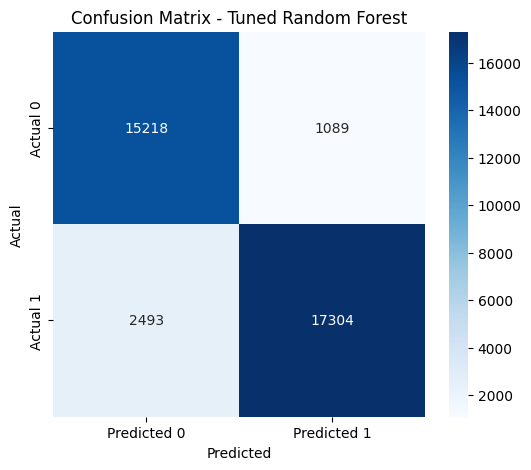

In [78]:
cm_rf = confusion_matrix(y_test, pred_ft_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

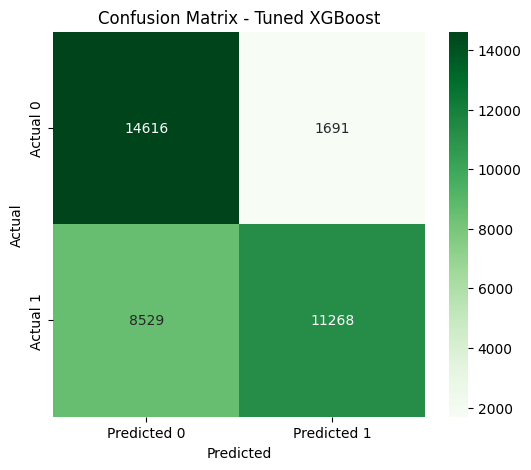

In [79]:
cm_xgb = confusion_matrix(y_test, pred_ft_xgb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

plt.title('Confusion Matrix - Tuned XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [80]:
print("===== RANDOM FOREST =====")
print(classification_report(
    y_test,
    pred_ft_rf,
    zero_division=0
))

print("\n===== XGBOOST =====")
print(classification_report(
    y_test,
    pred_ft_xgb,
    zero_division=0
))

===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       0.86      0.93      0.89     16307
           1       0.94      0.87      0.91     19797

    accuracy                           0.90     36104
   macro avg       0.90      0.90      0.90     36104
weighted avg       0.90      0.90      0.90     36104


===== XGBOOST =====
              precision    recall  f1-score   support

           0       0.63      0.90      0.74     16307
           1       0.87      0.57      0.69     19797

    accuracy                           0.72     36104
   macro avg       0.75      0.73      0.71     36104
weighted avg       0.76      0.72      0.71     36104



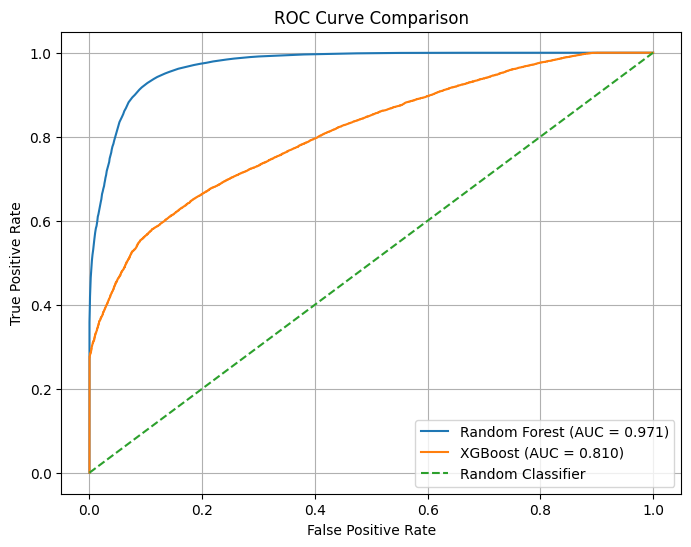

In [81]:
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    prob_ft_rf
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    prob_ft_xgb
)

auc_rf = roc_auc_score(y_test, prob_ft_rf)
auc_xgb = roc_auc_score(y_test, prob_ft_xgb)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.3f})'
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f'XGBoost (AUC = {auc_xgb:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()
plt.show()

In [82]:
# SHAP for Fine Tuned Random Forest

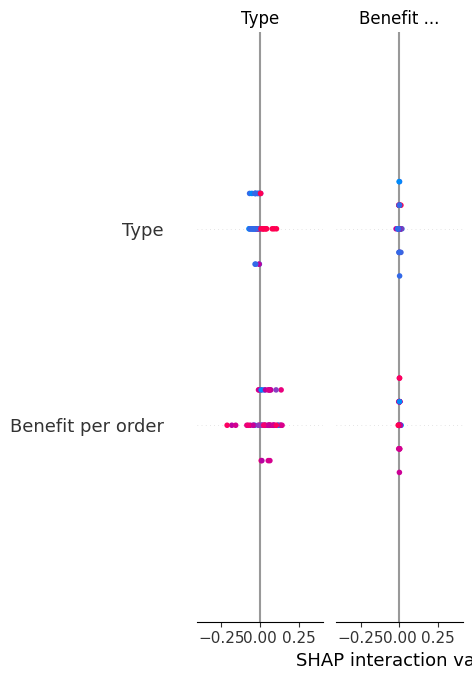

In [83]:
import shap

# Use only 50 test records
X_test_shap = X_test.sample(
    n=min(50, len(X_test)),
    random_state=42
)

# Create SHAP explainer
explainer_rf = shap.TreeExplainer(best_rf)

# Calculate SHAP values
shap_values_rf = explainer_rf.shap_values(X_test_shap)

# Plot
if isinstance(shap_values_rf, list):
    shap.summary_plot(shap_values_rf[1], X_test_shap)
else:
    shap.summary_plot(shap_values_rf, X_test_shap)

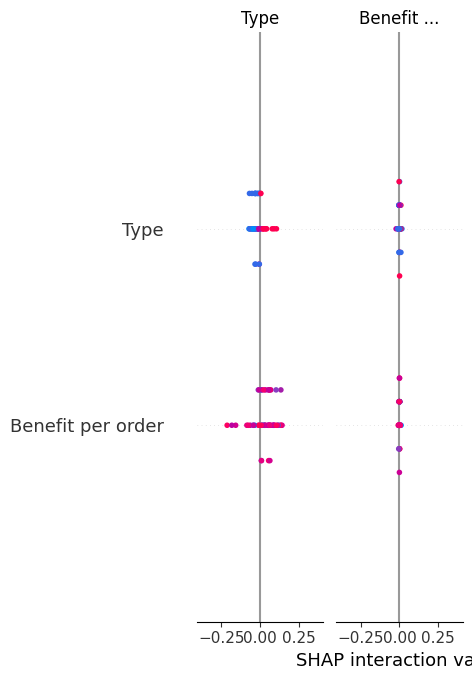

In [84]:
# XGBoost
shap.summary_plot(
    shap_values_rf,
    X_test_shap,
    plot_type="bar"
)

In [85]:
# SHAP for Fine Tuned XGBoost

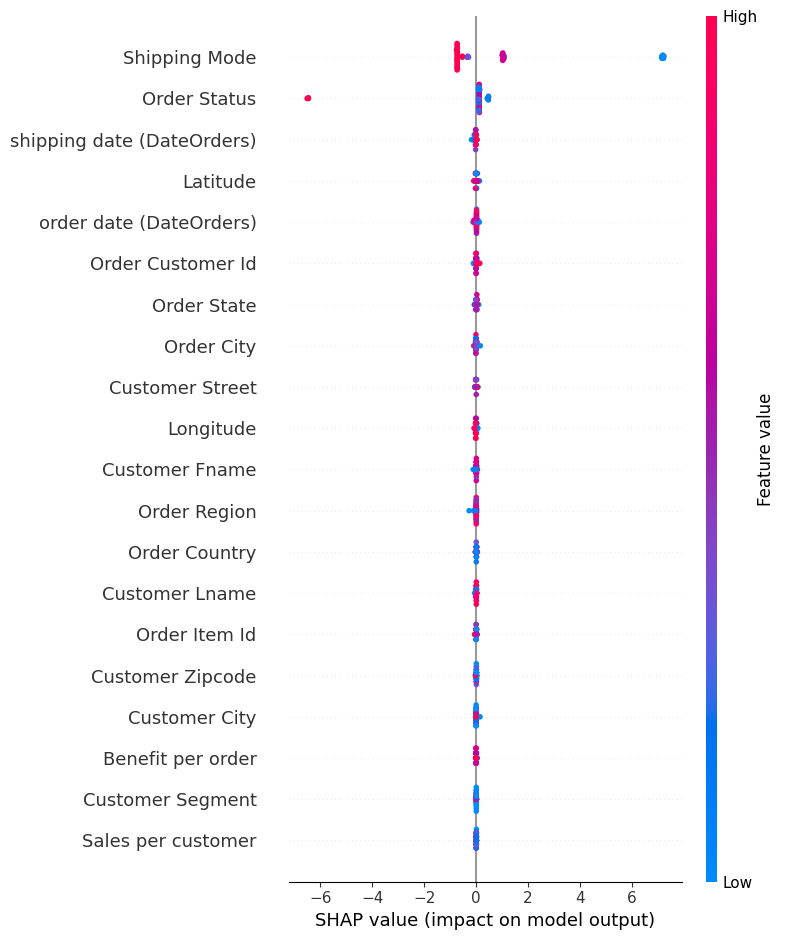

In [86]:
# XGBoost SHAP
explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test_shap)

# Summary plot
shap.summary_plot(shap_values_xgb, X_test_shap)

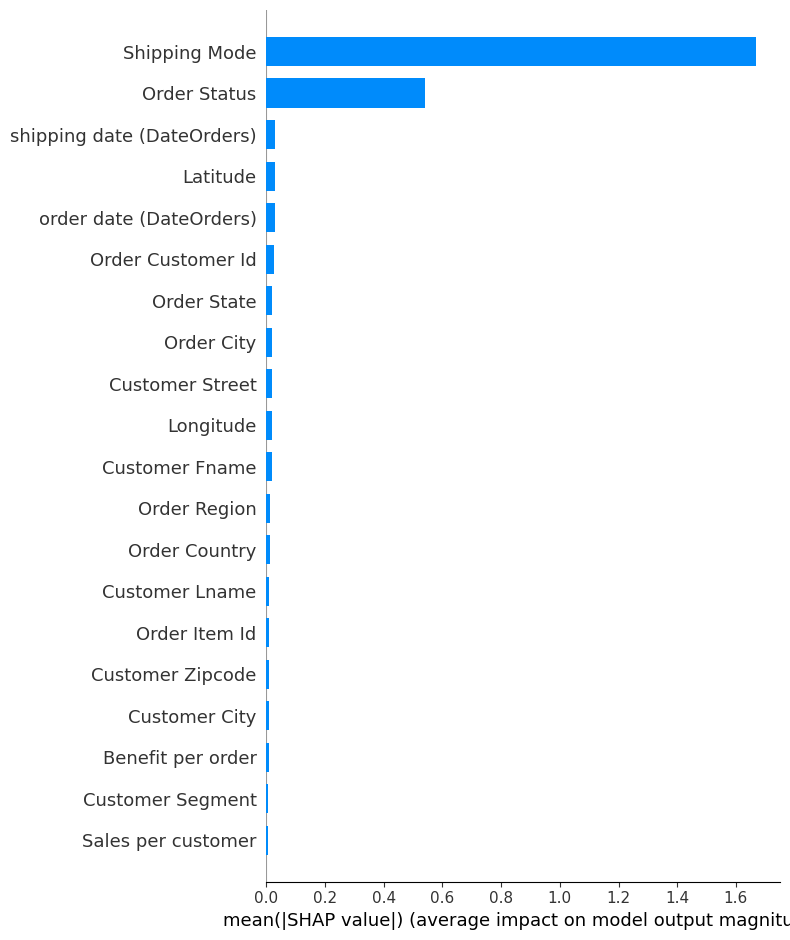

In [87]:
# XGBoost
shap.summary_plot(
    shap_values_xgb,
    X_test_shap,
    plot_type="bar"
)

In [88]:
models = {
    'Logistics Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb,
    'Fine Tuned Random Forest': best_rf,
    'Fine Tuned XGBoost': best_xgb
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=[
            'accuracy',
            'precision',
            'recall',
            'f1',
            'roc_auc'
        ],
        n_jobs=-1
    )

    cv_results.append({
        'Model': name,
        'CV Accuracy': scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall': scores['test_recall'].mean(),
        'CV F1': scores['test_f1'].mean(),
        'CV ROC-AUC': scores['test_roc_auc'].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

print(cv_results_df)

                      Model  CV Accuracy  CV Precision  CV Recall     CV F1  \
0      Logistics Regression     0.547921      0.548837   0.986183  0.705156   
1             Decision Tree     0.857418      0.870638   0.869083  0.869857   
2             Random Forest     0.836153      0.905421   0.782950  0.839742   
3                   XGBoost     0.793186      0.889792   0.710823  0.790282   
4  Fine Tuned Random Forest     0.839414      0.901906   0.793407  0.844184   
5        Fine Tuned XGBoost     0.724731      0.868153   0.587169  0.700494   

   CV ROC-AUC  
0    0.525698  
1    0.856171  
2    0.932843  
3    0.902189  
4    0.932580  
5    0.818320  


In [89]:
# Accuracy Comparison

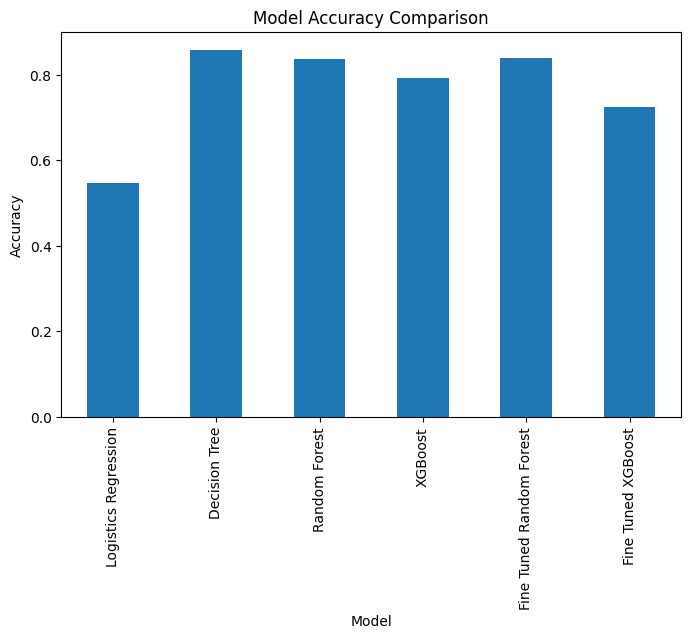

In [90]:
cv_results_df.set_index('Model')['CV Accuracy'].plot(

kind='bar',

figsize=(8,5)

)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

In [91]:
# Compare feature imporatnce across all model

feature_comparison = pd.DataFrame({
    'Feature': X_train.columns,

    'Logistic Regression':
        np.abs(lr.coef_[0]),

    'Decision Tree':
        dt.feature_importances_,

    'Random Forest':
        rf.feature_importances_,

    'XGBoost':
        xgb.feature_importances_,
    
    'Fine Tuned Random Forest':
        best_rf.feature_importances_,

    'Fine Tuned XGBoost':
        best_xgb.feature_importances_
})

print(feature_comparison.sort_values(
    by='Fine Tuned XGBoost',
    ascending=False
).head(15))

                       Feature  Logistic Regression  Decision Tree  \
41               Shipping Mode         7.803672e-03       0.210610   
34                Order Status         1.878447e-05       0.078491   
21     order date (DateOrders)         3.501269e-07       0.082397   
40  shipping date (DateOrders)         2.776935e-07       0.084954   
17                      Market         2.296981e-05       0.004538   
25               Order Item Id         2.723312e-07       0.052088   
16                   Longitude         8.912997e-04       0.033008   
9             Customer Segment         2.574664e-05       0.007668   
19               Order Country         6.830469e-04       0.021358   
20           Order Customer Id         2.172161e-06       0.048143   
18                  Order City         1.149505e-05       0.042469   
11             Customer Street         1.284936e-06       0.049570   
32                Order Region         8.899985e-04       0.012047   
0                   

In [92]:
!pip install joblib

import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(lr, "models/logistic_regression.pkl")
joblib.dump(dt, "models/decision_tree.pkl")
joblib.dump(rf, "models/random_forest.pkl")
joblib.dump(xgb, "models/xgboost.pkl")
joblib.dump(best_rf, "models/best_ft_random_forest.pkl")
joblib.dump(best_xgb, "models/best_ft_xgboost.pkl")

print("Models saved successfully!")


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Models saved successfully!


In [1]:
!git --version

git version 2.53.0.windows.3


In [2]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [ ]:
!git remote -v

In [ ]:
!git add models/
!git add Capstone_Project_28072026.ipynb
!git commit -m "Add trained models and updated notebook"
!git push origin main